# GRU, and how it compares to LSTM

### Two gates instead of three, and the comparison almost everyone runs wrong

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | The reset and update gates, why merging the cell state into the hidden state removes a whole gate, a GRU cell written by hand and checked against `nn.GRU`, the place PyTorch puts the reset gate that the original paper does not, why comparing a GRU to an LSTM at equal hidden size is not a fair fight, and the same two models compared at equal hidden size and at equal parameter count with accuracy, wall clock and sequence length all measured |
| **You should already know** | [LSTM](../04-lstm/) and [recurrent networks](../03-recurrent-neural-networks/). This notebook reuses their copy task and their training loop |
| **Dataset** | Fashion-MNIST read one row at a time as a 28-step sequence, plus the synthetic copy task from 09-04 |
| **Runtime** | Three to four minutes on a laptop CPU |
| **Next** | [09-06 Sequence to sequence with attention](../06-seq2seq-attention/) |

---

## 1. The idea

The [LSTM notebook](../04-lstm/) ended on a working architecture and an obvious
follow-up question. Four weight blocks, three gates, two states: is all of it
load bearing?

The GRU, published in 2014 by Cho and colleagues while they were building the
encoder-decoder that [09-06](../06-seq2seq-attention/) is about, is one answer.
It makes two cuts.

The first cut merges the two states. An LSTM keeps $c_t$, the memory, and $h_t$,
what the rest of the network is allowed to see, and an output gate decides how
much of the first becomes the second. A GRU keeps one vector and no output gate.
Whatever it remembers, it reports.

The second cut ties the forget and input gates together. In an LSTM those two are
independent: the cell can keep the old value *and* write the new one, or drop the
old value and write nothing. A GRU replaces them with a single **update gate**
$z_t$ and forms a weighted average, so keeping more of the old state necessarily
means writing less of the new one. Three gates become two, four weight blocks
become three.

That last sentence is where this notebook's real subject starts. Three blocks
instead of four means that at the same hidden size a GRU has three quarters of
the parameters. Almost every GRU-against-LSTM comparison you will read gives both
models the same `hidden_size` and reports the accuracies, and that comparison
carries a confound as large as the architecture difference itself. Section 4
runs it both ways.

In [1]:
import sys
import math
import time
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

# Weight blocks per cell: one matrix of each shape per gate, plus the candidate.
BLOCKS = {"RNN": 1, "GRU": 3, "LSTM": 4}

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}, running on {device}")
print("weight blocks per cell:", BLOCKS)

torch 2.11.0+cu128, running on cuda
weight blocks per cell: {'RNN': 1, 'GRU': 3, 'LSTM': 4}


## 2. The maths

Two gates, each an ordinary logistic layer reading the input and the previous
state:

$$r_t = \sigma\!\left(W_{ir} x_t + b_{ir} + W_{hr} h_{t-1} + b_{hr}\right)$$

$$z_t = \sigma\!\left(W_{iz} x_t + b_{iz} + W_{hz} h_{t-1} + b_{hz}\right)$$

a candidate state, which is the only part shaped like the plain RNN:

$$n_t = \tanh\!\left(W_{in} x_t + b_{in} + r_t \odot \left(W_{hn} h_{t-1} + b_{hn}\right)\right)$$

and the update, which is a weighted average:

$$h_t = (1 - z_t) \odot n_t + z_t \odot h_{t-1}$$

Two things are worth stopping on.

**In PyTorch's convention $z_t$ is the keep gate.** It multiplies the old state,
so $z_t$ near one means remember, and $z_t$ near zero means overwrite. Half the
literature writes the update the other way round, with $z_t$ on the candidate.
The architecture is the same; the sign of the gate is not, and if you initialise
a bias by copying a formula from the wrong source you get the opposite of what
you wanted. This matters below, because 09-04's helper adds a bias to the slice
`H:2H` of the input bias, which is the forget gate in an LSTM and the update gate
here, and in both it is the gate that decides how much survives one step.

**The reset gate sits inside the candidate, not on the state.** $r_t$ can cut the
old state out of the candidate without deleting it from $h_t$, which is how the
cell can start a fresh chunk of input without wiping what it already stored. It
is a different job from forgetting, and it is the job the LSTM has no gate for.

### The gradient path

Differentiate the update:

$$\frac{\partial h_t}{\partial h_{t-1}} = \operatorname{diag}(z_t) \; + \; \text{terms through } n_t \text{ and } z_t$$

The first term is the same trick as the LSTM's. It carries the gradient back one
step with no weight matrix and no $\tanh'$ in the way, scaled by a number the
network chooses per unit and per step. That is why the gradient sweep in
[09-04](../04-lstm/) put the GRU next to the LSTM and both a long way from the
plain RNN.

The difference is in the words "$+$ terms". The LSTM's memory path is
$\partial c_t / \partial c_{t-1} = \operatorname{diag}(f_t)$ exactly, with
nothing added, because everything else in that cell hangs off the road rather
than sitting on it. The GRU has one vector doing both jobs, so the extra
derivative terms are always present. On paper the LSTM's highway is cleaner.
Whether that shows up in a measurement is section 4's problem.

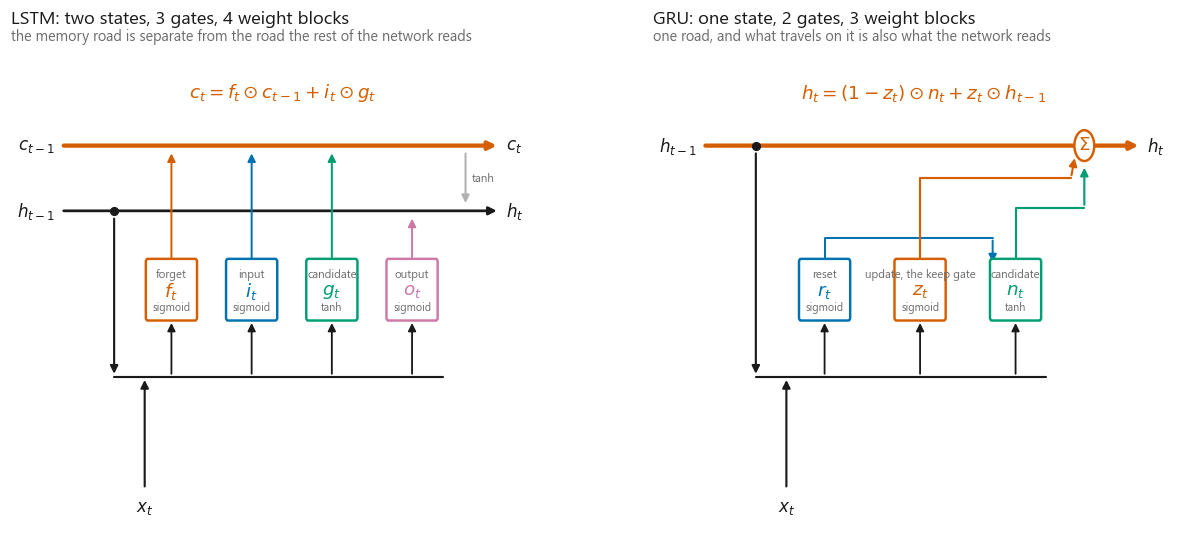

In [2]:
from matplotlib.patches import Circle, FancyBboxPatch


def node(ax, xy, symbol, colour, radius=0.26):
    ax.add_patch(Circle(xy, radius, facecolor="white", edgecolor=colour,
                        linewidth=1.6, zorder=4))
    ax.text(xy[0], xy[1] + 0.01, symbol, ha="center", va="center",
            fontsize=12, color=colour, zorder=5)


def wire(ax, points, colour, lw=1.5, head=True):
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    if head:
        if len(points) > 2:
            ax.plot(xs[:-1], ys[:-1], color=colour, lw=lw,
                    solid_capstyle="round", zorder=2)
        ax.annotate("", xy=points[-1], xytext=points[-2],
                    arrowprops=dict(arrowstyle="-|>", color=colour, lw=lw), zorder=2)
    else:
        ax.plot(xs, ys, color=colour, lw=lw, solid_capstyle="round", zorder=2)


def gate_box(ax, cx, name, symbol, activation, colour, bottom=1.7):
    ax.add_patch(FancyBboxPatch((cx - 0.62, bottom), 1.24, 0.94,
                                boxstyle="round,pad=0.05", linewidth=1.6,
                                edgecolor=colour, facecolor="white", zorder=3))
    ax.text(cx, bottom + 0.74, name, ha="center", va="center", fontsize=7.5,
            color=style.MUTED, zorder=4)
    ax.text(cx, bottom + 0.45, symbol, ha="center", va="center", fontsize=12,
            color=colour, zorder=4)
    ax.text(cx, bottom + 0.17, activation, ha="center", va="center", fontsize=7,
            color=style.MUTED, zorder=4)


BUS_Y, BOX_BOTTOM, BOX_TOP = 0.7, 1.7, 2.64
C_ROAD, H_ROAD = 4.6, 3.5


def road(ax, y, colour, lw, left_label, right_label):
    wire(ax, [(-1.1, y), (10.4, y)], colour, lw=lw)
    ax.text(-1.25, y, left_label, ha="right", va="center", fontsize=11, color=style.INK)
    ax.text(10.55, y, right_label, ha="left", va="center", fontsize=11, color=style.INK)


def feed_bus(ax, tap_y, x_input, right):
    """Previous state and current input joined and fanned out to every gate."""
    wire(ax, [(0.3, BUS_Y), (right, BUS_Y)], style.INK, lw=1.4, head=False)
    wire(ax, [(0.3, tap_y - 0.08), (0.3, BUS_Y)], style.INK, lw=1.4)
    ax.plot([0.3], [tap_y], marker="o", markersize=5, color=style.INK, zorder=5)
    wire(ax, [(x_input, -1.2), (x_input, BUS_Y)], style.INK, lw=1.4)
    ax.text(x_input, -1.36, "$x_t$", ha="center", va="top", fontsize=11,
            color=style.INK)


fig, axes = plt.subplots(1, 2, figsize=(13.8, 5.6))

# --- left panel: the LSTM, drawn as an inventory rather than as full wiring ---
ax = axes[0]
road(ax, C_ROAD, style.HIGHLIGHT, 2.8, "$c_{t-1}$", "$c_t$")
road(ax, H_ROAD, style.INK, 1.8, "$h_{t-1}$", "$h_t$")

lstm_boxes = [1.8, 3.9, 6.0, 8.1]
for cx, name, symbol, activation, colour, lands_on in zip(
        lstm_boxes, ["forget", "input", "candidate", "output"],
        ["$f_t$", "$i_t$", "$g_t$", "$o_t$"],
        ["sigmoid", "sigmoid", "tanh", "sigmoid"],
        [style.HIGHLIGHT, style.PALETTE[0], style.PALETTE[2], style.PALETTE[4]],
        [C_ROAD, C_ROAD, C_ROAD, H_ROAD]):
    gate_box(ax, cx, name, symbol, activation, colour)
    wire(ax, [(cx, BUS_Y), (cx, BOX_BOTTOM - 0.04)], style.INK, lw=1.2)
    wire(ax, [(cx, BOX_TOP), (cx, lands_on - 0.08)], colour, lw=1.3)

# what the rest of the network sees is read off the memory road, then gated
wire(ax, [(9.5, C_ROAD - 0.08), (9.5, H_ROAD + 0.08)], style.NEUTRAL, lw=1.3)
ax.text(9.66, (C_ROAD + H_ROAD) / 2, "tanh", ha="left", va="center", fontsize=7.5,
        color=style.MUTED)
feed_bus(ax, H_ROAD, 1.1, right=8.9)
ax.text(4.7, 5.5, "$c_t = f_t \\odot c_{t-1} + i_t \\odot g_t$",
        ha="center", va="center", fontsize=12, color=style.HIGHLIGHT)
ax.set_xlim(-2.4, 11.6)
ax.set_ylim(-1.9, 6.1)
ax.axis("off")
style.title(ax,
            f"LSTM: two states, {len(lstm_boxes) - 1} gates, "
            f"{BLOCKS['LSTM']} weight blocks",
            "the memory road is separate from the road the rest of the network "
            "reads")

# --- right panel: the GRU ---
ax = axes[1]
road(ax, C_ROAD, style.HIGHLIGHT, 2.8, "$h_{t-1}$", "$h_t$")
node(ax, (8.9, C_ROAD), "$\\Sigma$", style.HIGHLIGHT)

gru_boxes = [2.1, 4.6, 7.1]
for cx, name, symbol, activation, colour in zip(
        gru_boxes, ["reset", "update, the keep gate", "candidate"],
        ["$r_t$", "$z_t$", "$n_t$"], ["sigmoid", "sigmoid", "tanh"],
        [style.PALETTE[0], style.HIGHLIGHT, style.PALETTE[2]]):
    gate_box(ax, cx, name, symbol, activation, colour)
    wire(ax, [(cx, BUS_Y), (cx, BOX_BOTTOM - 0.04)], style.INK, lw=1.2)

# the reset gate feeds the candidate; update and candidate meet at the sum
wire(ax, [(2.1, BOX_TOP), (2.1, 3.05), (6.5, 3.05), (6.5, BOX_TOP - 0.06)],
     style.PALETTE[0], lw=1.3)
wire(ax, [(7.1, BOX_TOP), (7.1, 3.55), (8.9, 3.55), (8.9, C_ROAD - 0.32)],
     style.PALETTE[2], lw=1.4)
wire(ax, [(4.6, BOX_TOP), (4.6, 4.05), (8.55, 4.05), (8.66, C_ROAD - 0.16)],
     style.HIGHLIGHT, lw=1.4)
feed_bus(ax, C_ROAD, 1.1, right=7.9)
ax.text(4.7, 5.5, "$h_t = (1 - z_t) \\odot n_t + z_t \\odot h_{t-1}$",
        ha="center", va="center", fontsize=12, color=style.HIGHLIGHT)
ax.set_xlim(-2.4, 11.6)
ax.set_ylim(-1.9, 6.1)
ax.axis("off")
style.title(ax,
            f"GRU: one state, {len(gru_boxes) - 1} gates, "
            f"{BLOCKS['GRU']} weight blocks",
            "one road, and what travels on it is also what the network reads")

style.save(fig, FIG / "fig-01-gru-against-lstm.png")

Count the boxes. That is the entire architectural difference, and everything
measured below follows from it.

## 3. From scratch, checked against nn.GRU

Three gate computations reading the same two vectors, so in practice one matrix
multiply produces $3H$ numbers that get sliced into three blocks. PyTorch stacks
them as $r, z, n$, and keeps a separate bias for the input side and the hidden
side, which is not redundant here the way it was for the plain RNN. The reason is
the reset gate, and it is the next cell's subject.

In [3]:
class GRUCellFromScratch(nn.Module):
    """One step of the GRU recurrence. Gate order r, z, n, as in PyTorch."""

    def __init__(self, n_in, n_hidden):
        super().__init__()
        self.n_hidden = n_hidden
        bound = 1.0 / math.sqrt(n_hidden)
        self.W_ih = nn.Parameter(torch.empty(3 * n_hidden, n_in).uniform_(-bound, bound))
        self.W_hh = nn.Parameter(torch.empty(3 * n_hidden, n_hidden).uniform_(-bound, bound))
        self.b_ih = nn.Parameter(torch.empty(3 * n_hidden).uniform_(-bound, bound))
        self.b_hh = nn.Parameter(torch.empty(3 * n_hidden).uniform_(-bound, bound))

    def forward(self, x_t, h_prev, reset_before_matmul=False):
        gates_x = x_t @ self.W_ih.T + self.b_ih          # (B, 3H)
        gates_h = h_prev @ self.W_hh.T + self.b_hh       # (B, 3H)
        x_r, x_z, x_n = gates_x.chunk(3, dim=1)
        h_r, h_z, h_n = gates_h.chunk(3, dim=1)

        r = torch.sigmoid(x_r + h_r)
        z = torch.sigmoid(x_z + h_z)
        if reset_before_matmul:
            # The 2014 paper's version: reset the state, then multiply.
            W_hn = self.W_hh[2 * self.n_hidden:]
            b_hn = self.b_hh[2 * self.n_hidden:]
            n = torch.tanh(x_n + (r * h_prev) @ W_hn.T + b_hn)
        else:
            # PyTorch's version: multiply once, then reset the product.
            n = torch.tanh(x_n + r * h_n)
        h = (1 - z) * n + z * h_prev                     # a weighted average
        return h, {"r": r, "z": z, "n": n}


def unroll_gru(cell, x, h0=None, reset_before_matmul=False):
    """Run `cell` over the time axis of x, shaped (batch, time, features).

    Returns every hidden state, the final one, and every gate activation. Keeping
    the gates is the reason a hand-written cell is worth having: `nn.GRU` computes
    them and throws them away.
    """
    batch, n_steps, _ = x.shape
    h = (torch.zeros(batch, cell.n_hidden, dtype=x.dtype, device=x.device)
         if h0 is None else h0)
    states, log = [], []
    for t in range(n_steps):          # this loop is the recurrent network
        h, gates = cell(x[:, t], h, reset_before_matmul)
        states.append(h)
        log.append(gates)
    packed = {k: torch.stack([g[k] for g in log], dim=1) for k in ("r", "z", "n")}
    return torch.stack(states, 1), h, packed

In [4]:
n_in, n_hidden = 3, 16
torch.manual_seed(SEED)

reference = nn.GRU(input_size=n_in, hidden_size=n_hidden, batch_first=True)
mine = GRUCellFromScratch(n_in, n_hidden)

with torch.no_grad():
    mine.W_ih.copy_(reference.weight_ih_l0)
    mine.W_hh.copy_(reference.weight_hh_l0)
    mine.b_ih.copy_(reference.bias_ih_l0)
    mine.b_hh.copy_(reference.bias_hh_l0)

x_check = torch.randn(4, 12, n_in)
mine_states, mine_last, _ = unroll_gru(mine, x_check)
ref_states, ref_last = reference(x_check)

print(f"my states  {tuple(mine_states.shape)}   nn.GRU states  {tuple(ref_states.shape)}")
print(f"largest disagreement, all steps  : {(mine_states - ref_states).abs().max():.3e}")
print(f"largest disagreement, last state : {(mine_last - ref_last[0]).abs().max():.3e}")
assert torch.allclose(mine_states, ref_states, atol=1e-6)
print("\nthe hand-written loop and nn.GRU agree")

my states  (4, 12, 16)   nn.GRU states  (4, 12, 16)
largest disagreement, all steps  : 5.960e-08
largest disagreement, last state : 5.960e-08

the hand-written loop and nn.GRU agree


### The one line the paper and the library disagree about

Look again at the candidate. PyTorch computes

$$n_t = \tanh\!\left(W_{in} x_t + b_{in} + r_t \odot (W_{hn} h_{t-1} + b_{hn})\right)$$

and the 2014 paper computes

$$n_t = \tanh\!\left(W_{in} x_t + b_{in} + W_{hn} (r_t \odot h_{t-1}) + b_{hn}\right)$$

The reset gate is applied after the matrix multiply in one and before it in the
other. These are different functions. The library's version is not an
approximation of the paper's, and the paper's is not a bug in the library.

The reason PyTorch chose its version is speed: $W_{hh} h_{t-1}$ can be computed
once as a single $3H$-wide multiply for all three gates before anything is gated,
which is exactly what the `gates_h` line above does. The paper's version needs
$r_t$ first, so the candidate's hidden multiply cannot join the other two.

It also explains a detail that looks like sloppiness in the API. `nn.GRU` keeps
`bias_ih_l0` and `bias_hh_l0` separate, and for a plain RNN those two are
redundant because they only ever appear added together. Here $b_{hn}$ sits inside
the reset gate's multiply and $b_{in}$ sits outside it, so they are not
interchangeable and the pair has to stay.

Here is the size of the disagreement, with identical weights in both.

In [5]:
same_weights, _, _ = unroll_gru(mine, x_check, reset_before_matmul=False)
paper_version, _, _ = unroll_gru(mine, x_check, reset_before_matmul=True)

difference = (same_weights - paper_version).abs()
print(f"largest disagreement between the two formulations: {difference.max():.4f}")
print(f"mean absolute disagreement                       : {difference.mean():.4f}")
print(f"typical size of a hidden state value             : "
      f"{same_weights.abs().mean():.4f}")
print(f"\nsame weights, same input, two published definitions of 'the GRU'")

largest disagreement between the two formulations: 0.1368
mean absolute disagreement                       : 0.0414
typical size of a hidden state value             : 0.1466

same weights, same input, two published definitions of 'the GRU'


Not floating-point noise. Both are trainable and both work; the point is that
"the GRU" names two functions, and if you write the cell yourself from a paper
and then check it against `nn.GRU` you will find a mismatch and waste an hour
looking for a bug that is not there.

From here everything uses `nn.GRU`, which fuses the time loop into one kernel
instead of running it in Python.

## 4. Matching the two models honestly

One helper builds either cell, lifted from [09-04](../04-lstm/) so the two
notebooks are comparing the same objects.

In [6]:
def make_recurrent(kind, n_in, n_hidden, gate_bias=0.0, seed=SEED):
    """An nn.RNN, nn.LSTM or nn.GRU, optionally with a head start on memory.

    `gate_bias` is added to the bias of the gate that decides how much state
    survives one step: the forget gate in an LSTM, the update gate in a GRU.
    """
    torch.manual_seed(seed)
    if kind == "RNN":
        module = nn.RNN(n_in, n_hidden, batch_first=True, nonlinearity="tanh")
    elif kind == "LSTM":
        module = nn.LSTM(n_in, n_hidden, batch_first=True)
    elif kind == "GRU":
        module = nn.GRU(n_in, n_hidden, batch_first=True)
    else:
        raise ValueError(kind)

    if gate_bias and kind in ("LSTM", "GRU"):
        with torch.no_grad():
            # LSTM biases are stacked [i, f, g, o]; GRU biases are [r, z, n].
            # Slice H:2H is the forget gate in one and the update gate in the
            # other, and in both it is the one that controls how much survives.
            module.bias_ih_l0[n_hidden:2 * n_hidden] += gate_bias
    return module


GATE_BIAS = 1.0


def parameter_count(kind, n_in, n_hidden, n_out):
    """Recurrent weights and biases, plus the linear head that reads the state."""
    recurrent = BLOCKS[kind] * (n_hidden * n_in + n_hidden * n_hidden + 2 * n_hidden)
    return recurrent + n_hidden * n_out + n_out


def match_hidden(kind, target, n_in, n_out, ceiling=1024):
    """The hidden size that puts `kind` closest to `target` parameters."""
    sizes = np.arange(1, ceiling + 1)
    counts = np.array([parameter_count(kind, n_in, int(h), n_out) for h in sizes])
    return int(sizes[np.argmin(np.abs(counts - target))])


# The check that the formula matches what PyTorch actually allocates.
CHECK_IN, CHECK_HIDDEN, CHECK_OUT = 28, 64, 10
for kind in BLOCKS:
    rnn = make_recurrent(kind, CHECK_IN, CHECK_HIDDEN)
    head = nn.Linear(CHECK_HIDDEN, CHECK_OUT)
    allocated = (sum(p.numel() for p in rnn.parameters())
                 + sum(p.numel() for p in head.parameters()))
    predicted = parameter_count(kind, CHECK_IN, CHECK_HIDDEN, CHECK_OUT)
    print(f"{kind:<5} formula {predicted:>7,}   allocated {allocated:>7,}   "
          f"agree {predicted == allocated}")

RNN   formula   6,666   allocated   6,666   agree True
GRU   formula  18,698   allocated  18,698   agree True
LSTM  formula  24,714   allocated  24,714   agree True


### Why equal hidden size is not a fair fight

The parameter count of a recurrent layer is (blocks) times (input weights plus
recurrent weights plus two biases). The blocks are the only thing that changes
between the cells, so at any hidden size the GRU sits at three quarters of the
LSTM and the plain RNN at one quarter. The recurrent term dominates once the
hidden size passes the input width, so the ratio holds almost everywhere.

To match on parameters instead, the GRU needs a wider state. Since the count goes
like $3H^2$ against $4H^2$, the matched hidden size is around $H\sqrt{4/3}$, and
the exact integer is easier to search for than to solve for.

              task           model  parameters
Fashion-MNIST rows LSTM, hidden 64       24714
Fashion-MNIST rows  GRU, hidden 64       18698
Fashion-MNIST rows  GRU, hidden 76       24938
         copy task LSTM, hidden 32        5124
         copy task  GRU, hidden 32        3876
         copy task  GRU, hidden 37        5036

matched GRU hidden size, image task: 76 against the LSTM's 64
matched GRU hidden size, copy task : 37 against the LSTM's 32


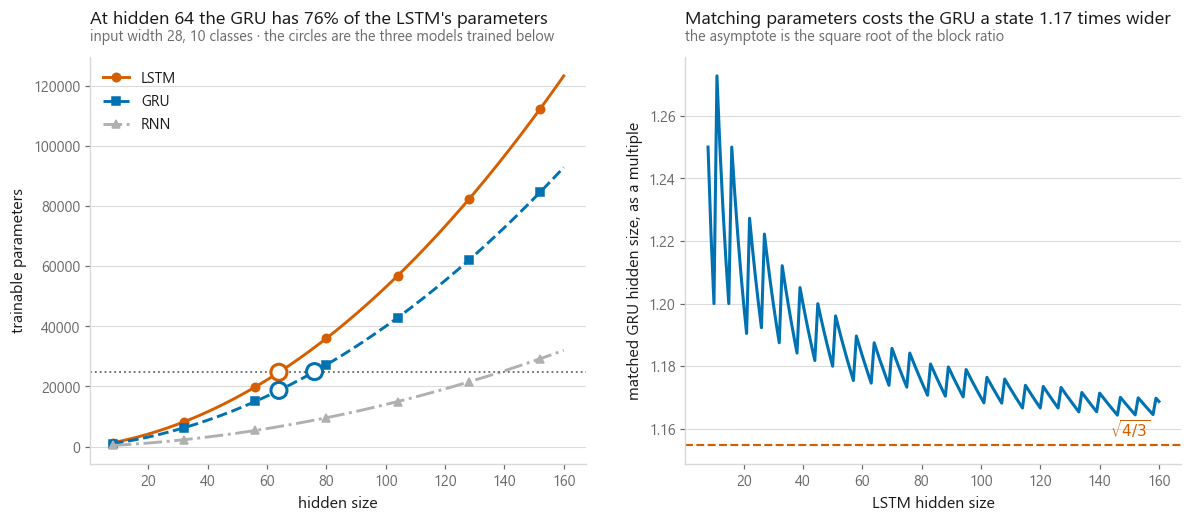

In [7]:
IMAGE_IN, IMAGE_OUT, IMAGE_HIDDEN = 28, 10, 64
COPY_IN, COPY_OUT, COPY_HIDDEN = 5, 4, 32

image_target = parameter_count("LSTM", IMAGE_IN, IMAGE_HIDDEN, IMAGE_OUT)
image_gru_matched = match_hidden("GRU", image_target, IMAGE_IN, IMAGE_OUT)
copy_target = parameter_count("LSTM", COPY_IN, COPY_HIDDEN, COPY_OUT)
copy_gru_matched = match_hidden("GRU", copy_target, COPY_IN, COPY_OUT)

sizes = np.arange(8, 161)
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

for i, kind in enumerate(["LSTM", "GRU", "RNN"]):
    axes[0].plot(sizes, [parameter_count(kind, IMAGE_IN, int(h), IMAGE_OUT) for h in sizes],
                 color=[style.HIGHLIGHT, style.PALETTE[0], style.NEUTRAL][i],
                 linestyle=style.DASHES[i], marker=style.MARKERS[i], markevery=24,
                 label=kind)
axes[0].axhline(image_target, color=style.MUTED, linestyle=":", linewidth=1.2)
axes[0].scatter([IMAGE_HIDDEN, IMAGE_HIDDEN, image_gru_matched],
                [image_target,
                 parameter_count("GRU", IMAGE_IN, IMAGE_HIDDEN, IMAGE_OUT),
                 parameter_count("GRU", IMAGE_IN, image_gru_matched, IMAGE_OUT)],
                s=110, zorder=5, facecolor="white",
                edgecolor=[style.HIGHLIGHT, style.PALETTE[0], style.PALETTE[0]],
                linewidth=2.0)
axes[0].set_xlabel("hidden size")
axes[0].set_ylabel("trainable parameters")
axes[0].legend()
gru_share = (parameter_count("GRU", IMAGE_IN, IMAGE_HIDDEN, IMAGE_OUT)
             / image_target)
style.title(axes[0],
            f"At hidden {IMAGE_HIDDEN} the GRU has {gru_share:.0%} of the LSTM's "
            f"parameters",
            f"input width {IMAGE_IN}, {IMAGE_OUT} classes · the circles are the "
            f"three models trained below")

ratios = np.array([match_hidden("GRU", parameter_count("LSTM", IMAGE_IN, int(h), IMAGE_OUT),
                                IMAGE_IN, IMAGE_OUT) / h for h in sizes])
axes[1].plot(sizes, ratios, color=style.PALETTE[0], linewidth=2.0)
axes[1].axhline(math.sqrt(4 / 3), color=style.HIGHLIGHT, linestyle="--", linewidth=1.4)
axes[1].annotate(r"$\sqrt{4/3}$", xy=(sizes[-1], math.sqrt(4 / 3)), xytext=(-6, 6),
                 textcoords="offset points", ha="right", fontsize=10,
                 color=style.HIGHLIGHT)
axes[1].set_xlabel("LSTM hidden size")
axes[1].set_ylabel("matched GRU hidden size, as a multiple")
style.title(axes[1],
            f"Matching parameters costs the GRU a state "
            f"{ratios[-1]:.2f} times wider",
            "the asymptote is the square root of the block ratio")

style.save(fig, FIG / "fig-02-parameter-matching.png")

matching = pd.DataFrame([
    {"task": "Fashion-MNIST rows", "model": f"LSTM, hidden {IMAGE_HIDDEN}",
     "parameters": parameter_count("LSTM", IMAGE_IN, IMAGE_HIDDEN, IMAGE_OUT)},
    {"task": "Fashion-MNIST rows", "model": f"GRU, hidden {IMAGE_HIDDEN}",
     "parameters": parameter_count("GRU", IMAGE_IN, IMAGE_HIDDEN, IMAGE_OUT)},
    {"task": "Fashion-MNIST rows", "model": f"GRU, hidden {image_gru_matched}",
     "parameters": parameter_count("GRU", IMAGE_IN, image_gru_matched, IMAGE_OUT)},
    {"task": "copy task", "model": f"LSTM, hidden {COPY_HIDDEN}",
     "parameters": parameter_count("LSTM", COPY_IN, COPY_HIDDEN, COPY_OUT)},
    {"task": "copy task", "model": f"GRU, hidden {COPY_HIDDEN}",
     "parameters": parameter_count("GRU", COPY_IN, COPY_HIDDEN, COPY_OUT)},
    {"task": "copy task", "model": f"GRU, hidden {copy_gru_matched}",
     "parameters": parameter_count("GRU", COPY_IN, copy_gru_matched, COPY_OUT)},
])
print(matching.to_string(index=False))
print(f"\nmatched GRU hidden size, image task: {image_gru_matched} "
      f"against the LSTM's {IMAGE_HIDDEN}")
print(f"matched GRU hidden size, copy task : {copy_gru_matched} "
      f"against the LSTM's {COPY_HIDDEN}")

Three models per task from here on, and the naming is worth fixing in your head.
The **equal hidden** GRU is the comparison everyone runs, and it hands the LSTM a
capacity advantage. The **equal parameters** GRU is the comparison that isolates
the architecture, and it hands the GRU a wider state. Neither is the right one on
its own. Printing both is the point.

## 5. Task one: Fashion-MNIST, one row at a time

A square greyscale image read as a sequence of rows, each row one time step.
This is a deliberately awkward way to look at an image and
[Part 8](../../08-computer-vision/) would beat it with a convolution and far
fewer parameters. It is here because it is a real classification task with a
real accuracy number, and because the sequence is short enough that memory is
not the bottleneck, which makes it the opposite case to the copy task below.

In [8]:
from torch.utils.data import TensorDataset, DataLoader

N_TRAIN, N_TEST = 10_000, 2_000
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]


def as_rows(dataset, n=None, seed=SEED):
    """Materialise images as (batch, 28 steps, 28 features) float tensors."""
    labels = dataset.targets
    if n is None:
        keep = torch.arange(len(labels))
    else:
        keep = torch.randperm(len(labels), generator=torch.Generator().manual_seed(seed))[:n]
    images = dataset.data[keep].float().div_(255.0)      # (n, 28, 28), rows are steps
    return images, labels[keep].clone()


x_train, y_train = as_rows(datasets.fashion_mnist(train=True), N_TRAIN)
x_test, y_test = as_rows(datasets.fashion_mnist(train=False), N_TEST)
x_train, y_train = x_train.to(device), y_train.to(device)
x_test, y_test = x_test.to(device), y_test.to(device)

print(f"training tensor {tuple(x_train.shape)}: "
      f"{x_train.shape[0]:,} images, {x_train.shape[1]} steps, "
      f"{x_train.shape[2]} features per step")
print(f"test tensor     {tuple(x_test.shape)}")
print(f"pixel range {x_train.min():.1f} to {x_train.max():.1f}, "
      f"{len(CLASSES)} classes, so guessing scores {1 / len(CLASSES):.2f}")

training tensor (10000, 28, 28): 10,000 images, 28 steps, 28 features per step
test tensor     (2000, 28, 28)
pixel range 0.0 to 1.0, 10 classes, so guessing scores 0.10


In [9]:
class SequenceClassifier(nn.Module):
    """Read the whole sequence, classify from the final hidden state."""

    def __init__(self, kind, n_in, n_hidden, n_out, gate_bias=GATE_BIAS):
        super().__init__()
        self.rnn = make_recurrent(kind, n_in, n_hidden, gate_bias)
        self.head = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.head(out[:, -1])


def train_classifier(model, X_tr, y_tr, X_te, y_te, epochs=12, lr=3e-3,
                     batch_size=128, clip=1.0, seed=SEED):
    """09-04's loop, with the clock started so wall time per epoch comes out too."""
    generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size,
                        shuffle=True, generator=generator)
    loss_fn = nn.CrossEntropyLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)
    curve, epoch_seconds = [], []

    for _ in range(epochs):
        model.train()
        started = time.perf_counter()
        for xb, yb in loader:
            optimiser.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), clip)   # fair fight
            optimiser.step()
        if device == "cuda":
            torch.cuda.synchronize()
        epoch_seconds.append(time.perf_counter() - started)

        model.eval()
        with torch.no_grad():
            curve.append(float((model(X_te).argmax(1) == y_te).float().mean()))
    return curve, float(np.median(epoch_seconds))


LSTM_NAME = f"LSTM, hidden {IMAGE_HIDDEN}"
GRU_EQUAL_NAME = f"GRU, hidden {IMAGE_HIDDEN}, equal hidden"
GRU_MATCHED_NAME = f"GRU, hidden {image_gru_matched}, equal parameters"

CONFIGS = [("LSTM", IMAGE_HIDDEN, LSTM_NAME),
           ("GRU", IMAGE_HIDDEN, GRU_EQUAL_NAME),
           ("GRU", image_gru_matched, GRU_MATCHED_NAME)]
CONFIG_COLOURS = [style.HIGHLIGHT, style.NEUTRAL, style.PALETTE[0]]
SHORT_LABELS = [f"LSTM\nh={IMAGE_HIDDEN}", f"GRU\nh={IMAGE_HIDDEN}\nequal hidden",
                f"GRU\nh={image_gru_matched}\nequal params"]
LEGEND_LABELS = [f"LSTM, h={IMAGE_HIDDEN}",
                 f"GRU, h={IMAGE_HIDDEN} (equal hidden)",
                 f"GRU, h={image_gru_matched} (equal params)"]

image_rows, image_curves = [], {}
started_all = time.perf_counter()
for (kind, hidden, name), colour in zip(CONFIGS, CONFIG_COLOURS):
    torch.manual_seed(SEED)
    model = SequenceClassifier(kind, IMAGE_IN, hidden, IMAGE_OUT).to(device)
    curve, seconds = train_classifier(model, x_train, y_train, x_test, y_test)
    image_curves[name] = curve
    image_rows.append({
        "model": name, "hidden": hidden,
        "parameters": sum(p.numel() for p in model.parameters()),
        "test accuracy": round(curve[-1], 4),
        "best epoch": round(max(curve), 4),
        "s per epoch": round(seconds, 2),
    })
    print(f"{name:<38} accuracy {curve[-1]:.4f}   {seconds:.2f} s per epoch")

image_results = pd.DataFrame(image_rows)
print(f"\ntrained {len(CONFIGS)} models in {time.perf_counter() - started_all:.0f} s")
print(image_results.to_string(index=False))

winner = image_results.loc[image_results["test accuracy"].idxmax(), "model"]
spread = image_results["test accuracy"].max() - image_results["test accuracy"].min()
speedup = (image_results.loc[0, "s per epoch"]
           / image_results.loc[1, "s per epoch"])
matched_speedup = (image_results.loc[0, "s per epoch"]
                   / image_results.loc[2, "s per epoch"])
print(f"\nbest accuracy: {winner}")
print(f"spread across the three: {spread:.4f} accuracy")
print(f"LSTM epoch time against the equal-hidden GRU  : {speedup:.2f}x")
print(f"LSTM epoch time against the equal-parameter GRU: {matched_speedup:.2f}x")

LSTM, hidden 64                        accuracy 0.8540   0.51 s per epoch


GRU, hidden 64, equal hidden           accuracy 0.8510   0.50 s per epoch


GRU, hidden 76, equal parameters       accuracy 0.8560   0.52 s per epoch

trained 3 models in 19 s
                           model  hidden  parameters  test accuracy  best epoch  s per epoch
                 LSTM, hidden 64      64       24714          0.854       0.854         0.51
    GRU, hidden 64, equal hidden      64       18698          0.851       0.852         0.50
GRU, hidden 76, equal parameters      76       24938          0.856       0.856         0.52

best accuracy: GRU, hidden 76, equal parameters
spread across the three: 0.0050 accuracy
LSTM epoch time against the equal-hidden GRU  : 1.02x
LSTM epoch time against the equal-parameter GRU: 0.98x


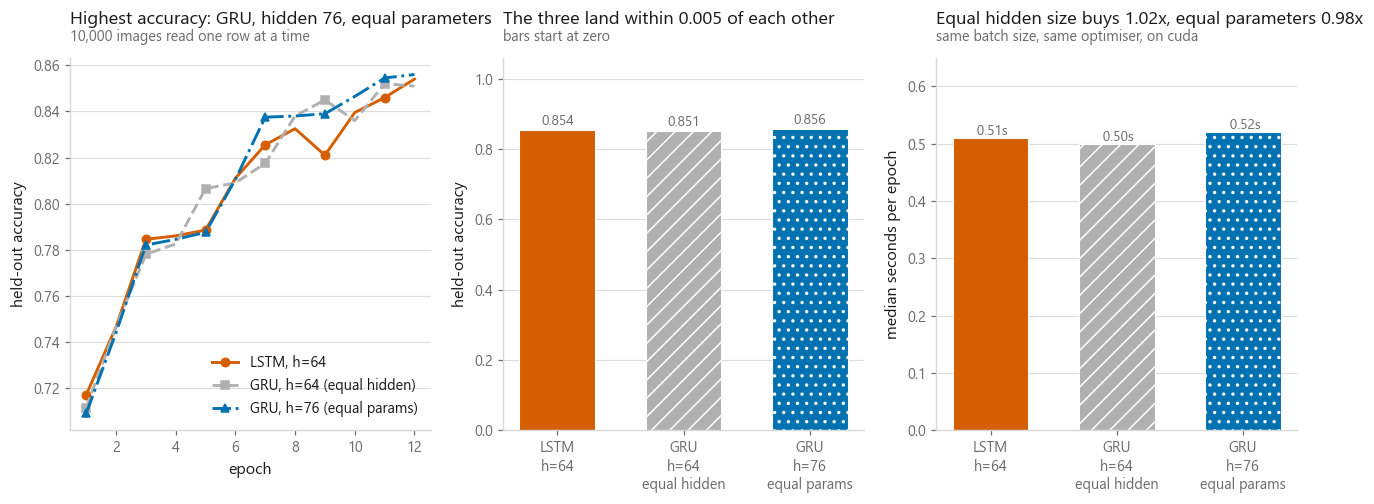

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.4))

for i, ((name, curve), label) in enumerate(zip(image_curves.items(), LEGEND_LABELS)):
    axes[0].plot(np.arange(1, len(curve) + 1), curve, color=CONFIG_COLOURS[i],
                 marker=style.MARKERS[i], linestyle=style.DASHES[i],
                 markevery=2, label=label)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("held-out accuracy")
axes[0].legend()
style.title(axes[0], f"Highest accuracy: {winner}",
            f"{N_TRAIN:,} images read one row at a time")

names = list(image_results["model"])
accuracy_values = list(image_results["test accuracy"])
bars = axes[1].bar(range(len(names)), accuracy_values, color=CONFIG_COLOURS,
                   width=0.6, hatch=["", "//", ".."], edgecolor="white")
for rect, value in zip(bars, accuracy_values):
    axes[1].text(rect.get_x() + rect.get_width() / 2, value + 0.006, f"{value:.3f}",
                 ha="center", va="bottom", fontsize=9, color=style.MUTED)
axes[1].set_xticks(range(len(names)), SHORT_LABELS)
axes[1].set_ylim(0, 1.06)
axes[1].set_ylabel("held-out accuracy")
style.title(axes[1], f"The three land within {spread:.3f} of each other",
            "bars start at zero")

seconds_values = list(image_results["s per epoch"])
bars = axes[2].bar(range(len(names)), seconds_values, color=CONFIG_COLOURS,
                   width=0.6, hatch=["", "//", ".."], edgecolor="white")
for rect, value in zip(bars, seconds_values):
    axes[2].text(rect.get_x() + rect.get_width() / 2, value, f" {value:.2f}s",
                 ha="center", va="bottom", fontsize=9, color=style.MUTED)
axes[2].set_xticks(range(len(names)), SHORT_LABELS)
axes[2].set_ylim(0, max(seconds_values) * 1.25)
axes[2].set_ylabel("median seconds per epoch")
style.title(axes[2],
            f"Equal hidden size buys {speedup:.2f}x, equal parameters "
            f"{matched_speedup:.2f}x",
            f"same batch size, same optimiser, on {device}")

style.save(fig, FIG / "fig-03-fashion-mnist.png")

The middle and right panels together are the reason this notebook exists. Read
the accuracy spread against the two epoch-time ratios, and remember that the two
GRU columns are the same architecture at two sizes. If you only ever ran the
equal-hidden comparison you would report one of those speed numbers as "the GRU
is faster", and a reader would reasonably assume the accuracies were comparable
at comparable cost.

The honest version has three rows in it, which is why the table above has three.

## 6. Task two: a dependency across the whole sequence

Twenty-eight steps is short. Nothing in the image task needs a state to survive
more than a few steps, so the memory machinery both cells were designed for is
barely being asked for.

The copy task from [09-04](../04-lstm/) is the opposite. At the first step the
model sees a symbol together with a flag saying "this one counts". Then a run of
random symbols with the flag off, which it must ignore. At the last step it says
which symbol was flagged. The lag is the only thing that changes, and nothing
about the task needs capacity: it needs one fact carried across the gap
untouched.

In [11]:
N_SYMBOLS = 4


def make_copy_task(n, lag, rng):
    """(n, lag+1, N_SYMBOLS+1) inputs; the label is the symbol at the flagged step."""
    n_steps = lag + 1
    tokens = rng.integers(0, N_SYMBOLS, size=(n, n_steps))
    X = np.zeros((n, n_steps, N_SYMBOLS + 1), dtype=np.float32)
    rows = np.arange(n)[:, None]
    X[rows, np.arange(n_steps)[None, :], tokens] = 1.0
    X[:, 0, N_SYMBOLS] = 1.0        # the flag, on for the first step only
    return X, tokens[:, 0].astype(np.int64)


COPY_CONFIGS = [("LSTM", COPY_HIDDEN, f"LSTM, hidden {COPY_HIDDEN}"),
                ("GRU", COPY_HIDDEN, f"GRU, hidden {COPY_HIDDEN}, equal hidden"),
                ("GRU", copy_gru_matched,
                 f"GRU, hidden {copy_gru_matched}, equal parameters")]
LAGS = [2, 8, 16, 32, 64, 100]
N_COPY_TRAIN, N_COPY_TEST = 2000, 600

demo_rng = np.random.default_rng(SEED)
demo_X, demo_y = make_copy_task(2, lag=5, rng=demo_rng)
print("one sequence at lag 5, one row per step, one-hot symbol then the flag:")
print(demo_X[0].astype(int))
print(f"\nlabel: symbol {demo_y[0]}, seen at step 0. Chance is "
      f"{1 / N_SYMBOLS:.2f}")

one sequence at lag 5, one row per step, one-hot symbol then the flag:
[[0 0 0 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]
 [0 1 0 0 0]
 [0 1 0 0 0]
 [1 0 0 0 0]]

label: symbol 3, seen at step 0. Chance is 0.25


In [12]:
copy_accuracy = {name: [] for _, _, name in COPY_CONFIGS}
copy_seconds = {name: [] for _, _, name in COPY_CONFIGS}

started_all = time.perf_counter()
for lag in LAGS:
    rng = np.random.default_rng(SEED + lag)
    X_tr, y_tr = make_copy_task(N_COPY_TRAIN, lag, rng)
    X_te, y_te = make_copy_task(N_COPY_TEST, lag, rng)
    tensors = (torch.tensor(X_tr).to(device), torch.tensor(y_tr).to(device),
               torch.tensor(X_te).to(device), torch.tensor(y_te).to(device))

    for kind, hidden, name in COPY_CONFIGS:
        torch.manual_seed(SEED)
        model = SequenceClassifier(kind, N_SYMBOLS + 1, hidden, N_SYMBOLS).to(device)
        curve, seconds = train_classifier(model, *tensors, epochs=18, lr=5e-3,
                                          batch_size=64)
        copy_accuracy[name].append(curve[-1])
        copy_seconds[name].append(seconds)

    print(f"lag {lag:>3}   " + "   ".join(
        f"{short} {copy_accuracy[name][-1]:.3f}"
        for short, (_, _, name) in zip(["LSTM", "GRU equal-h", "GRU equal-p"],
                                       COPY_CONFIGS)))

print(f"\ntrained {len(LAGS) * len(COPY_CONFIGS)} models in "
      f"{time.perf_counter() - started_all:.0f} s")

SOLVED = 0.9
for _, _, name in COPY_CONFIGS:
    scores = np.array(copy_accuracy[name])
    passed = [lag for lag, a in zip(LAGS, scores) if a >= SOLVED]
    print(f"{name:<40} longest lag at {SOLVED:.0%}: "
          f"{max(passed) if passed else 'none'}"
          f"    accuracy at lag {LAGS[-1]}: {scores[-1]:.3f}")

lag   2   LSTM 1.000   GRU equal-h 1.000   GRU equal-p 1.000


lag   8   LSTM 1.000   GRU equal-h 1.000   GRU equal-p 1.000


lag  16   LSTM 0.510   GRU equal-h 1.000   GRU equal-p 1.000


lag  32   LSTM 1.000   GRU equal-h 1.000   GRU equal-p 1.000


lag  64   LSTM 0.242   GRU equal-h 0.270   GRU equal-p 1.000


lag 100   LSTM 0.232   GRU equal-h 0.243   GRU equal-p 0.233

trained 18 models in 71 s
LSTM, hidden 32                          longest lag at 90%: 32    accuracy at lag 100: 0.232
GRU, hidden 32, equal hidden             longest lag at 90%: 32    accuracy at lag 100: 0.243
GRU, hidden 37, equal parameters         longest lag at 90%: 64    accuracy at lag 100: 0.233


### Is the difference bigger than the noise?

A single seed per point is enough to see a curve fall over, and nowhere near
enough to rank two models that finish close together. Before reading anything
into the gaps above, here is the same comparison at one lag with three seeds
each, so the spread between seeds can be put next to the spread between
architectures.

In [13]:
SPREAD_LAG = 32
SPREAD_SEEDS = [0, 1, 2]

spread_scores = {name: [] for _, _, name in COPY_CONFIGS}
for seed in SPREAD_SEEDS:
    rng = np.random.default_rng(1000 + seed)
    X_tr, y_tr = make_copy_task(N_COPY_TRAIN, SPREAD_LAG, rng)
    X_te, y_te = make_copy_task(N_COPY_TEST, SPREAD_LAG, rng)
    tensors = (torch.tensor(X_tr).to(device), torch.tensor(y_tr).to(device),
               torch.tensor(X_te).to(device), torch.tensor(y_te).to(device))
    for kind, hidden, name in COPY_CONFIGS:
        torch.manual_seed(seed)
        model = SequenceClassifier(kind, N_SYMBOLS + 1, hidden, N_SYMBOLS,
                                   gate_bias=GATE_BIAS).to(device)
        curve, _ = train_classifier(model, *tensors, epochs=18, lr=5e-3,
                                    batch_size=64, seed=seed)
        spread_scores[name].append(curve[-1])

summary = pd.DataFrame([
    {"model": name,
     "mean": round(float(np.mean(spread_scores[name])), 3),
     "min": round(float(np.min(spread_scores[name])), 3),
     "max": round(float(np.max(spread_scores[name])), 3),
     "seed spread": round(float(np.ptp(spread_scores[name])), 3)}
    for _, _, name in COPY_CONFIGS])
print(f"lag {SPREAD_LAG}, {len(SPREAD_SEEDS)} seeds each\n")
print(summary.to_string(index=False))

between_models = float(summary["mean"].max() - summary["mean"].min())
worst_seed_spread = float(summary["seed spread"].max())
print(f"\nlargest gap between model means : {between_models:.3f}")
print(f"largest spread within one model : {worst_seed_spread:.3f}")
print("a gap smaller than the spread is not a result")

lag 32, 3 seeds each

                           model  mean   min  max  seed spread
                 LSTM, hidden 32 0.944 0.832  1.0        0.168
    GRU, hidden 32, equal hidden 1.000 1.000  1.0        0.000
GRU, hidden 37, equal parameters 1.000 1.000  1.0        0.000

largest gap between model means : 0.056
largest spread within one model : 0.168
a gap smaller than the spread is not a result


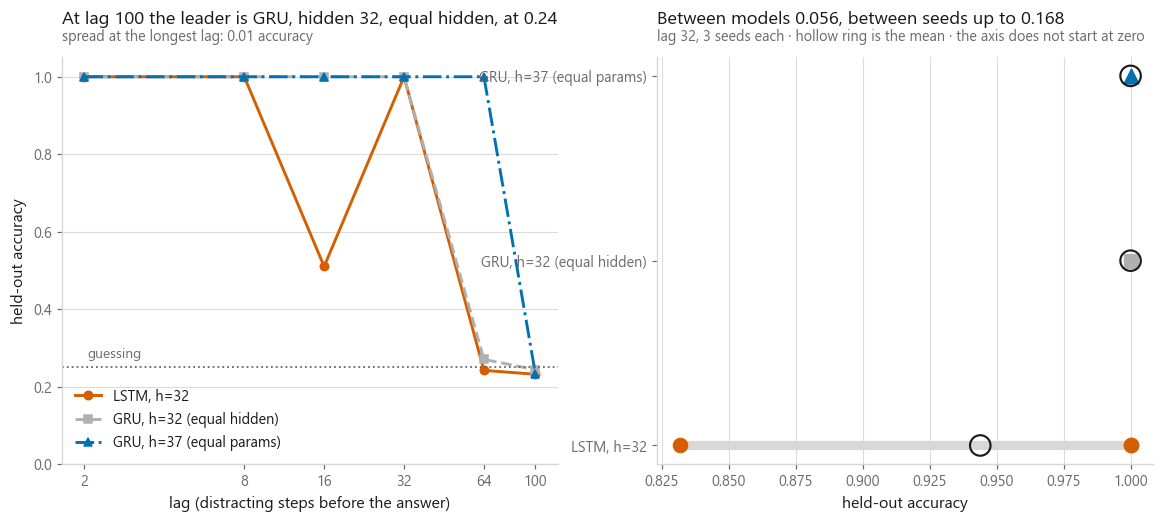

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

COPY_LEGEND = [f"LSTM, h={COPY_HIDDEN}",
               f"GRU, h={COPY_HIDDEN} (equal hidden)",
               f"GRU, h={copy_gru_matched} (equal params)"]

for i, (_, _, name) in enumerate(COPY_CONFIGS):
    axes[0].plot(LAGS, copy_accuracy[name], marker=style.MARKERS[i],
                 color=CONFIG_COLOURS[i], linestyle=style.DASHES[i],
                 label=COPY_LEGEND[i])
axes[0].axhline(1 / N_SYMBOLS, color=style.MUTED, linestyle=":", linewidth=1.2)
axes[0].annotate("guessing", xy=(LAGS[0], 1 / N_SYMBOLS), xytext=(2, 6),
                 textcoords="offset points", fontsize=9, color=style.MUTED)
axes[0].set_xscale("log", base=2)
axes[0].minorticks_off()
axes[0].set_xticks(LAGS, [str(lag) for lag in LAGS])
axes[0].set_ylim(0, 1.05)
axes[0].set_xlabel("lag (distracting steps before the answer)")
axes[0].set_ylabel("held-out accuracy")
axes[0].legend()
final = {name: copy_accuracy[name][-1] for _, _, name in COPY_CONFIGS}
leader = max(final, key=final.get)
style.title(axes[0],
            f"At lag {LAGS[-1]} the leader is {leader}, at {final[leader]:.2f}",
            f"spread at the longest lag: {max(final.values()) - min(final.values()):.2f} "
            f"accuracy")

for i, (_, _, name) in enumerate(COPY_CONFIGS):
    values = spread_scores[name]
    axes[1].plot([min(values), max(values)], [i, i], color=style.RULE, lw=6,
                 zorder=1, solid_capstyle="round")
    axes[1].scatter(values, [i] * len(values), s=90, color=CONFIG_COLOURS[i],
                    marker=style.MARKERS[i], zorder=3)
    axes[1].scatter([np.mean(values)], [i], s=180, facecolor="none",
                    edgecolor=style.INK, linewidth=1.4, zorder=4)
axes[1].set_yticks(range(len(COPY_CONFIGS)), COPY_LEGEND)
axes[1].set_xlabel("held-out accuracy")
axes[1].grid(axis="y", visible=False)
axes[1].grid(axis="x", visible=True)
style.title(axes[1],
            f"Between models {between_models:.3f}, between seeds up to "
            f"{worst_seed_spread:.3f}",
            f"lag {SPREAD_LAG}, {len(SPREAD_SEEDS)} seeds each · hollow ring is "
            f"the mean · the axis does not start at zero")

style.save(fig, FIG / "fig-04-copy-task.png")

Read the right panel before drawing a conclusion from the left one. If the gap
between the model means is smaller than the spread one model shows across seeds,
then the ordering on the left is a property of `torch.manual_seed(0)` and not of
the architecture. This is the check that turns a benchmark into a measurement,
and it is the one most comparisons of these two cells skip.

## 7. Wall clock as the sequence gets longer

The accuracy comparison needed care. The timing comparison does not, and it is
the one place the GRU has a guaranteed advantage, so it is worth pinning down
exactly how large the advantage is and whether it survives the parameter
matching.

One forward and one backward pass over a fixed batch, no training, at a range of
sequence lengths.

In [15]:
def bench(kind, n_hidden, n_steps, n_in=IMAGE_IN, batch=64, iters=12):
    """Milliseconds for one forward and backward pass over a fixed input."""
    module = make_recurrent(kind, n_in, n_hidden, GATE_BIAS).to(device)
    x = torch.randn(batch, n_steps, n_in, device=device)

    for _ in range(3):                       # warm up allocators and kernels
        module.zero_grad()
        module(x)[0].pow(2).sum().backward()
    if device == "cuda":
        torch.cuda.synchronize()

    start = time.perf_counter()
    for _ in range(iters):
        module.zero_grad()
        module(x)[0].pow(2).sum().backward()
    if device == "cuda":
        torch.cuda.synchronize()
    return (time.perf_counter() - start) / iters * 1000


STEP_GRID = [10, 25, 50, 100, 200, 400]
timings = {name: [bench(kind, hidden, n) for n in STEP_GRID]
           for kind, hidden, name in CONFIGS}

timing_table = pd.DataFrame(timings, index=[f"{n} steps" for n in STEP_GRID]).T
print(timing_table.round(2).to_string())

equal_hidden_ratio = np.array(timings[LSTM_NAME]) / np.array(timings[GRU_EQUAL_NAME])
equal_params_ratio = np.array(timings[LSTM_NAME]) / np.array(timings[GRU_MATCHED_NAME])
length_factor = timings[LSTM_NAME][-1] / timings[LSTM_NAME][0]
length_growth = STEP_GRID[-1] / STEP_GRID[0]

print(f"\nLSTM / GRU time, equal hidden size : "
      f"{equal_hidden_ratio.min():.2f}x to {equal_hidden_ratio.max():.2f}x")
print(f"LSTM / GRU time, equal parameters  : "
      f"{equal_params_ratio.min():.2f}x to {equal_params_ratio.max():.2f}x")
print(f"LSTM cost from {STEP_GRID[0]} to {STEP_GRID[-1]} steps: "
      f"{length_factor:.1f}x for a {length_growth:.0f}x longer sequence")

                                  10 steps  25 steps  50 steps  100 steps  200 steps  400 steps
LSTM, hidden 64                       3.07      3.00      2.86       3.20       3.28       5.32
GRU, hidden 64, equal hidden          2.69      2.85      3.09       3.15       3.36       5.81
GRU, hidden 76, equal parameters      3.13      3.12      3.13       2.66       4.83       8.52

LSTM / GRU time, equal hidden size : 0.92x to 1.14x
LSTM / GRU time, equal parameters  : 0.62x to 1.20x
LSTM cost from 10 to 400 steps: 1.7x for a 40x longer sequence


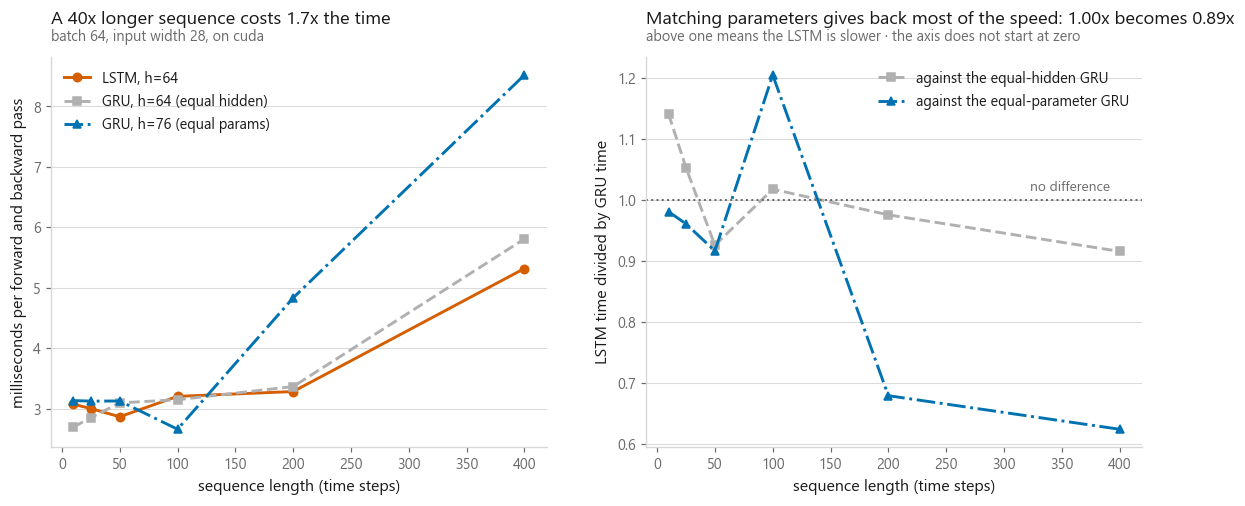

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.6))

for i, (name, values) in enumerate(timings.items()):
    axes[0].plot(STEP_GRID, values, marker=style.MARKERS[i],
                 color=CONFIG_COLOURS[i], linestyle=style.DASHES[i],
                 label=LEGEND_LABELS[i])
axes[0].set_xlabel("sequence length (time steps)")
axes[0].set_ylabel("milliseconds per forward and backward pass")
axes[0].legend()
style.title(axes[0],
            f"A {length_growth:.0f}x longer sequence costs {length_factor:.1f}x "
            f"the time",
            f"batch 64, input width {IMAGE_IN}, on {device}")

axes[1].plot(STEP_GRID, equal_hidden_ratio, marker=style.MARKERS[1],
             color=style.NEUTRAL, linestyle=style.DASHES[1],
             label="against the equal-hidden GRU")
axes[1].plot(STEP_GRID, equal_params_ratio, marker=style.MARKERS[2],
             color=style.PALETTE[0], linestyle=style.DASHES[2],
             label="against the equal-parameter GRU")
axes[1].axhline(1.0, color=style.MUTED, linestyle=":", linewidth=1.3)
axes[1].annotate("no difference", xy=(STEP_GRID[-1], 1.0), xytext=(-6, 6),
                 textcoords="offset points", ha="right", fontsize=9,
                 color=style.MUTED)
axes[1].set_xlabel("sequence length (time steps)")
axes[1].set_ylabel("LSTM time divided by GRU time")
axes[1].legend()
style.title(axes[1],
            f"Matching parameters gives back most of the speed: "
            f"{equal_hidden_ratio.mean():.2f}x becomes "
            f"{equal_params_ratio.mean():.2f}x",
            "above one means the LSTM is slower · the axis does not start at zero")

style.save(fig, FIG / "fig-05-wall-clock.png")

The right panel is the measurement that decides how much the speed argument is
worth. Per-step cost is dominated by the recurrent matrix multiplies, and those
scale with the same $\text{blocks} \times H^2$ that the parameter count does, so
two models matched on parameters are close to matched on arithmetic as well. The
printed ratios say how close.

So the GRU is faster at the same hidden size because it is a smaller model. That
is a real and useful fact when you are choosing a hidden size under a latency
budget. It is not the same claim as "the GRU is a faster architecture", and the
two get conflated constantly.

## 8. When to reach for which

Everything above is one seed per point on the sweeps, three seeds at one lag, two
tasks, and one machine. The tables are the result; here is how I would use them.

Published comparisons of these two cells mostly end without a winner, and the
tables above are one more small piece of evidence rather than a tiebreaker. Put
the gap between the model means next to the spread one model showed across
seeds: whenever the second is the larger of the two, the honest answer is
"either, and spend the time you saved on something that matters more".

Reasons to prefer a GRU: fewer parameters at a given hidden size, so faster and
lighter when the hidden size is fixed by something outside your control; one
state instead of two, so the plumbing is simpler when you start writing custom
decoders in [09-06](../06-seq2seq-attention/); and one gate fewer to reason about
when you are staring at activations.

Reasons to prefer an LSTM: the separate cell state and output gate let it hold
something without exposing it, which is a real capability the GRU lacks, and the
memory path is exactly $\operatorname{diag}(f_t)$ with nothing added, which is
the cleanest gradient highway of the two. If your task has a long dependency and
a GRU is not learning it, this is the first thing to try.

The one thing I would not do is copy a comparison table from a blog post that
matched hidden sizes. Section 4 is the reason.

## Cheat sheet

| | |
|---|---|
| **The update** | `h = (1 - z) * n + z * h_prev`. A weighted average, so keeping more of the old state means writing less of the new one |
| **The gates** | $r_t$ resets the state inside the candidate, $z_t$ decides how much of the old state survives. No output gate |
| **PyTorch's $z$** | Multiplies `h_prev`, so it is the keep gate. Half the literature defines it the other way round |
| **Gate order** | `weight_ih_l0` stacks $[r, z, n]$; an LSTM stacks $[i, f, g, o]$. Slice `H:2H` is the memory gate in both |
| **The reset gate's place** | PyTorch: `r * (W_hn h + b_hn)`. The 2014 paper: `W_hn (r * h)`. Different functions, and why `nn.GRU` keeps two bias vectors |
| **Parameters** | Three blocks against the LSTM's four, so $3/4$ at the same hidden size. Matching parameters needs a hidden size about $\sqrt{4/3}$ larger |
| **Comparing them** | Report equal hidden size and equal parameters. One of them is always flattering somebody |
| **Speed** | Faster at equal hidden size because it is smaller. Matched on parameters, most of that goes away |
| **Seeds** | Run several before ranking two cells. The gap between them is often inside the gap between seeds |
| **Returns** | `nn.GRU` returns `(output, h_n)`, one tensor for the state, where `nn.LSTM` returns a tuple `(h_n, c_n)` |
| **Next** | [Sequence to sequence with attention](../06-seq2seq-attention/), which uses a GRU as both encoder and decoder |

## What to remember

1. The GRU merges the LSTM's two states into one and its forget and input gates
   into one update gate. Two gates, three weight blocks, no output gate.
2. The gradient still has a highway, $\operatorname{diag}(z_t)$, but unlike the
   LSTM's cell state there are other terms alongside it, because one vector is
   doing both the remembering and the reporting.
3. PyTorch applies the reset gate after the hidden matrix multiply and the
   original paper applies it before. The two disagree by more than floating-point
   noise, and the printed comparison above says by how much.
4. At equal hidden size a GRU has three quarters of an LSTM's parameters. A
   comparison that fixes `hidden_size` is comparing two model sizes as well as
   two architectures.
5. Matching parameters instead means giving the GRU a hidden size about
   $\sqrt{4/3}$ times larger, and it takes most of the speed advantage back,
   because per-step arithmetic scales with parameters.
6. Report both matchings. Either one alone is a defensible experiment and a
   misleading headline.
7. Before ranking the two, measure the seed spread. If the gap between models is
   inside the spread within one model, you have measured your random seed.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [09-06 Sequence to sequence with attention](../06-seq2seq-attention/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#GRU` `#LSTM` `#RNN` `#PyTorch`
`#MachineLearning` `#Python` `#MLTutorial` `#LearnMachineLearning` `#AI`